# Reverse proxy benchmark analysis

Reads `bench/results.jsonl` (one row per wrk run, produced by `bench/harness.sh`) and compares optimization stages. Re-run any time you append new rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json("../bench/results.jsonl", lines=True)
# preserve the order stages were actually run in, not alphabetical
df["stage"] = pd.Categorical(df["stage"], categories=list(dict.fromkeys(df["stage"])), ordered=True)
df.tail()

,timestamp,stage,commit,concurrency,wrk_threads,duration,repeat,req_per_sec,transfer_per_sec_mb,latency_avg_ms,latency_stdev_ms,latency_max_ms,p50_ms,p75_ms,p90_ms,p99_ms,errors
13,2026-07-21 17:07:11,base-setup,09730c2,500,4,30s,2,6023.43,0.832939,31.20,86.49,NaN,NaN,NaN,NaN,NaN,0
14,2026-07-21 17:07:43,base-setup,09730c2,500,4,30s,3,5654.17,0.781875,30.56,77.41,NaN,NaN,NaN,NaN,NaN,0
15,2026-07-21 17:08:14,base-setup,09730c2,1000,4,30s,1,5409.09,0.747988,34.94,97.64,NaN,NaN,NaN,NaN,NaN,0
16,2026-07-21 17:08:46,base-setup,09730c2,1000,4,30s,2,5568.70,0.770059,31.28,81.03,NaN,NaN,NaN,NaN,NaN,0
17,2026-07-21 17:09:17,base-setup,09730c2,1000,4,30s,3,5486.94,0.758750,31.77,81.64,NaN,NaN,NaN,NaN,NaN,0


## 1. Throughput vs concurrency, per stage

Line chart, one line per stage, x = concurrency, y = mean req/sec across repeats with a shaded min-max band. This is the primary chart: it shows not just *did it get faster* but *where* it got faster — does the gain hold at c=1000, or did it only help at c=10 before something else became the bottleneck.

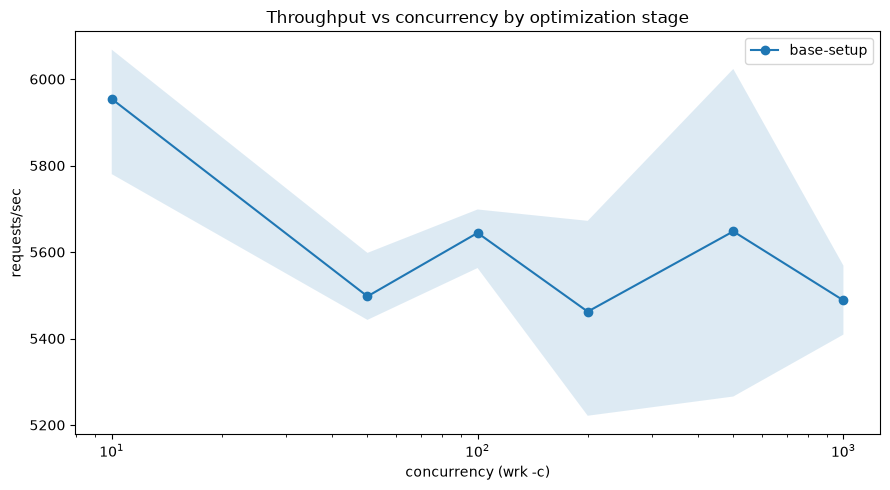

In [2]:
agg = df.groupby(["stage", "concurrency"])["req_per_sec"].agg(["mean", "min", "max"]).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for stage, g in agg.groupby("stage"):
    g = g.sort_values("concurrency")
    ax.plot(g["concurrency"], g["mean"], marker="o", label=stage)
    ax.fill_between(g["concurrency"], g["min"], g["max"], alpha=0.15)
ax.set_xlabel("concurrency (wrk -c)")
ax.set_ylabel("requests/sec")
ax.set_title("Throughput vs concurrency by optimization stage")
ax.legend()
ax.set_xscale("log")
plt.tight_layout()

## 2. Latency percentiles per stage, at a fixed concurrency

Grouped bar chart: p50/p90/p99 side by side per stage, at whichever concurrency you're treating as 'realistic load' (e.g. 100). Averages hide tail behavior — a change that helps req/sec but blows up p99 is a regression a throughput-only chart would hide.

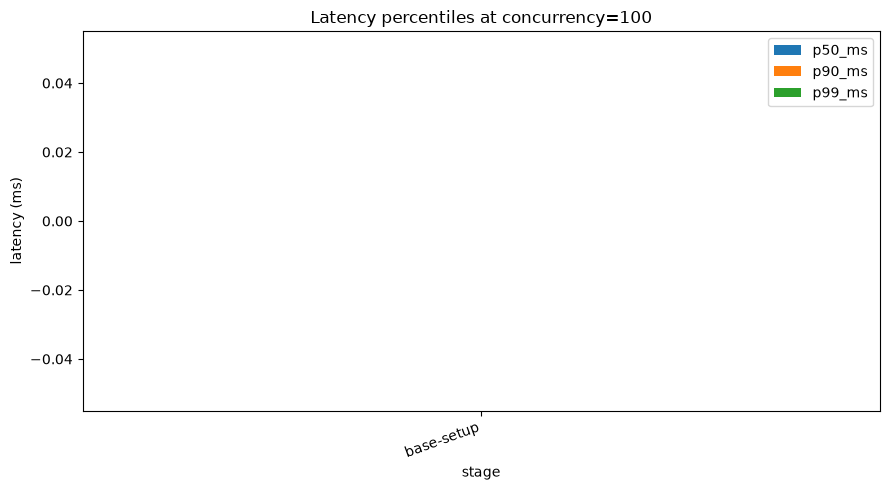

In [3]:
FOCUS_CONCURRENCY = 100  # change to whatever load level matters for your report

pct = (df[df["concurrency"] == FOCUS_CONCURRENCY]
       .groupby("stage")[["p50_ms", "p90_ms", "p99_ms"]].mean())

ax = pct.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("latency (ms)")
ax.set_title(f"Latency percentiles at concurrency={FOCUS_CONCURRENCY}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

## 3. Improvement waterfall

Bar chart of peak throughput (max over concurrency) per stage, in the order you applied them, with the % delta from the previous stage annotated. This is the one chart that answers 'what actually mattered' at a glance — good for the report's executive summary.

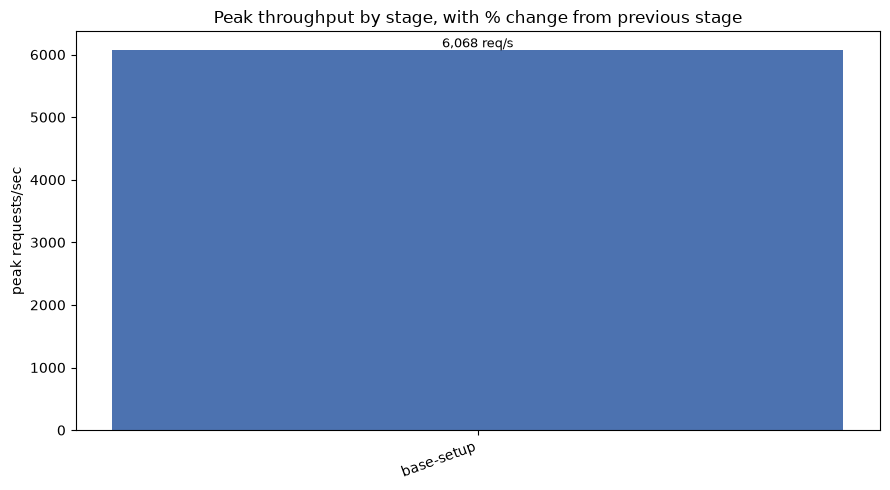

In [4]:
peak = df.groupby("stage")["req_per_sec"].max().reindex(df["stage"].cat.categories)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(peak.index.astype(str), peak.values, color="#4C72B0")
prev = None
for bar, val in zip(bars, peak.values):
    label = f"{val:,.0f} req/s"
    if prev is not None:
        label += f"\n({(val/prev - 1)*100:+.1f}%)"
    ax.text(bar.get_x() + bar.get_width()/2, val, label, ha="center", va="bottom", fontsize=9)
    prev = val
ax.set_ylabel("peak requests/sec")
ax.set_title("Peak throughput by stage, with % change from previous stage")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

## 4. Efficiency: req/sec per unit CPU

Only meaningful if you also log CPU% per run (see note below) — a stage that's faster *and* burns less CPU (e.g. fewer syscalls via a bigger relay buffer) is a different, better kind of win than one that's faster only because it's spawning more OS threads. If you're not capturing CPU yet: wrap the proxy process in `pidstat 1 -p $(pgrep reverse-proxy)` during each run and add a `cpu_pct` column to the harness's parsed row.

Skip this section until that column exists — no point plotting a column of NaNs.

In [5]:
if "cpu_pct" in df.columns and df["cpu_pct"].notna().any():
    eff = df.groupby("stage").apply(lambda g: g["req_per_sec"].mean() / g["cpu_pct"].mean())
    eff.plot(kind="bar", figsize=(9, 5), color="#55A868", ylabel="req/sec per CPU%")
    plt.title("Throughput per unit CPU by stage")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
else:
    print("no cpu_pct column yet - see markdown note above")

no cpu_pct column yet - see markdown note above


## 5. Final comparison: thread-per-connection vs epoll

Same throughput-vs-concurrency line chart as §1, filtered to just the final threaded stage and the final epoll stage, plus a second panel showing p99-latency-vs-concurrency for both. Two models can post similar req/sec while one's tail latency degrades much earlier as connections pile up — that's usually the actual story an epoll rewrite is sold on, so show it explicitly rather than leaving it implied by the throughput number alone.

/tmp/ipykernel_820448/202198621.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].set_title("Throughput"); axes[0].legend()
/tmp/ipykernel_820448/202198621.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].set_title("Tail latency"); axes[1].legend()


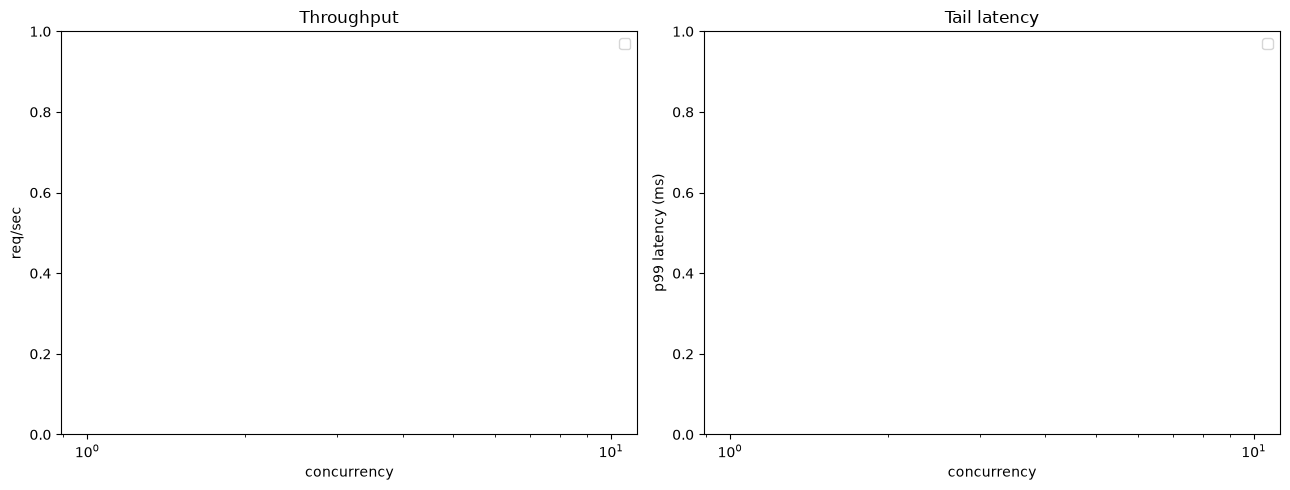

In [6]:
FINAL_THREADED = "threaded-final"   # set to your actual final threaded stage label
FINAL_EPOLL = "epoll-final"          # set to your actual final epoll stage label

final = df[df["stage"].isin([FINAL_THREADED, FINAL_EPOLL])]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for stage, g in final.groupby("stage"):
    g = g.groupby("concurrency")["req_per_sec"].mean().sort_index()
    axes[0].plot(g.index, g.values, marker="o", label=stage)
axes[0].set_xscale("log"); axes[0].set_xlabel("concurrency"); axes[0].set_ylabel("req/sec")
axes[0].set_title("Throughput"); axes[0].legend()

for stage, g in final.groupby("stage"):
    g = g.groupby("concurrency")["p99_ms"].mean().sort_index()
    axes[1].plot(g.index, g.values, marker="o", label=stage)
axes[1].set_xscale("log"); axes[1].set_xlabel("concurrency"); axes[1].set_ylabel("p99 latency (ms)")
axes[1].set_title("Tail latency"); axes[1].legend()

plt.tight_layout()